In [43]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Estatística
from scipy import stats

# Machine Learning (pré-processamento e seleção de features)
from sklearn.preprocessing import (
    OneHotEncoder, OrdinalEncoder, LabelEncoder,
    MinMaxScaler, StandardScaler
)
from sklearn.feature_selection import SelectKBest, f_classif, f_regression, RFE
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 50)

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


# 1. Carregamento e Inspeção Inicial

In [33]:
df_sales = pd.read_csv('../data/raw/sales.csv')
df_products = pd.read_csv('../data/raw/products.csv')
df_customers = pd.read_csv('../data/raw/customers.csv')

# Unindo vendas e clientes
df_unificado = pd.merge(df_sales, df_customers, on='Customer_ID')

# Unindo o resultado com os produtos
df_dataset = pd.merge(df_unificado, df_products, on='Product_ID')

In [34]:
# Exibindo as primeiras linhas do dataset unificado
df_dataset.head()

,Order_ID,Customer_ID,Product_ID,Order_Date,Order_Time,Delivery_Date,Quantity,Unit_Price,Order_Value,Shipping_Cost,Coupon_Code,Coupon_Discount,Total_Amount,Payment_Mode,Order_Status,Rating,Review_Text,City_x,State_x,Customer_Age,Customer_Age_Group,Customer_Name,Gender,Age,Age_Group,Date_of_Birth,Email,Phone,City_y,State_y,Pincode,Registration_Date,Customer_Tier,Total_Orders,Total_Spent,Product_Name,Category,Brand,Original_Price,Discount_Percent,Discount_Amount,Selling_Price,Stock_Quantity,Weight_kg,Avg_Rating,Total_Reviews
0,ORD0000000001,CUST00014303,PROD001017,2026-06-07,08:20:00,2026-06-10,1,2622.46,2622.46,0.0,NaN,0.0,2622.46,COD,Delivered,NaN,NaN,Chennai,Tamil Nadu,43,36-45,Suresh Shah,male,43,36-45,1982-01-12,sureshshah@yahoo.com,+91-8432380922,Chennai,Tamil Nadu,505798,2023-06-29,Platinum,5,319715.47,HP Laptop V7,Electronics,HP,3746.37,30,1123.91,2622.46,290,4.63,4.49,110
1,ORD0000000002,CUST00034253,PROD000703,2025-02-04,20:05:00,2025-02-07,1,90258.00,90258.00,0.0,NaN,0.0,90258.00,COD,Delivered,4.0,Nice quality,Durgapur,West Bengal,22,18-25,Amit Nair,male,22,18-25,2003-01-07,amitnair121@gmail.com,+91-7498436596,Durgapur,West Bengal,177443,2023-12-03,Platinum,3,218963.05,boAt Headphones V3,Electronics,boAt,145577.42,38,55319.42,90258.00,572,3.98,4.38,104
2,ORD0000000003,CUST00000421,PROD000318,2026-03-12,14:59:00,2026-03-19,1,3536.50,3536.50,0.0,NaN,0.0,3536.50,UPI,Processing,NaN,NaN,Patiala,Punjab,41,36-45,Aliya Khan,female,41,36-45,1984-01-12,aliyakhan@yahoo.com,+91-9111697218,Patiala,Punjab,891443,2023-06-14,Platinum,7,201868.75,boAt Headphones V8,Electronics,boAt,7073.01,50,3536.51,3536.50,749,3.61,4.32,109
3,ORD0000000004,CUST00026507,PROD000213,2025-01-27,14:33:00,2025-02-02,1,34081.56,34081.56,0.0,FLAT50,50.0,34031.56,Credit Card,Delivered,NaN,NaN,Rajkot,Gujarat,29,26-35,Kavya Gupta,female,29,26-35,1996-01-09,kavyagupta862@yahoo.com,+91-9953635765,Rajkot,Gujarat,537887,2023-06-20,Platinum,8,473269.13,boAt Headphones V2,Electronics,boAt,43141.21,21,9059.65,34081.56,743,0.70,4.43,116
4,ORD0000000005,CUST00009418,PROD001437,2024-06-30,07:19:00,2024-07-02,2,69021.17,138042.34,0.0,NaN,0.0,138042.34,UPI,Delivered,NaN,NaN,Surat,Gujarat,39,36-45,Suresh Tiwari,male,39,36-45,1986-01-11,sureshtiwari584@gmail.com,+91-9294706553,Surat,Gujarat,802766,2023-12-17,Platinum,5,539781.79,HP Laptop V10,Electronics,HP,73426.78,6,4405.61,69021.17,81,1.21,4.30,100


In [35]:
# Exibindo as últimas linhas do dataset 
df_dataset.tail()

,Order_ID,Customer_ID,Product_ID,Order_Date,Order_Time,Delivery_Date,Quantity,Unit_Price,Order_Value,Shipping_Cost,Coupon_Code,Coupon_Discount,Total_Amount,Payment_Mode,Order_Status,Rating,Review_Text,City_x,State_x,Customer_Age,Customer_Age_Group,Customer_Name,Gender,Age,Age_Group,Date_of_Birth,Email,Phone,City_y,State_y,Pincode,Registration_Date,Customer_Tier,Total_Orders,Total_Spent,Product_Name,Category,Brand,Original_Price,Discount_Percent,Discount_Amount,Selling_Price,Stock_Quantity,Weight_kg,Avg_Rating,Total_Reviews
249995,ORD0000249996,CUST00008137,PROD001818,2024-10-06,19:17:00,2024-10-08,1,1827.96,1827.96,0.0,NaN,0.0,1827.96,COD,Processing,NaN,NaN,Sohna,Haryana,37,36-45,Suresh Iyer,male,37,36-45,1988-01-11,sureshiyer@outlook.com,+91-8170754778,Sohna,Haryana,608430,2023-10-07,Gold,4,34912.28,Lays Chips V5,Grocery,Lays,1924.17,5,96.21,1827.96,803,2.48,4.44,50
249996,ORD0000249997,CUST00027003,PROD000955,2024-08-28,05:26:00,2024-08-31,1,4040.86,4040.86,0.0,NaN,0.0,4040.86,UPI,Delivered,3.0,Could be better,Mangalore,Karnataka,34,26-35,Megha Verma,female,34,26-35,1991-01-10,meghaverma833@outlook.com,+91-7885897028,Mangalore,Karnataka,914535,2023-10-31,Gold,3,24897.06,Puma T-shirt V5,Fashion,Puma,4540.29,11,499.43,4040.86,797,1.87,4.44,90
249997,ORD0000249998,CUST00027511,PROD001894,2025-12-09,13:44:00,2025-12-12,2,10516.60,21033.20,0.0,NaN,0.0,21033.20,UPI,Delivered,4.0,Value for money,Delhi NCR,Delhi,21,18-25,Salman Ahmed,male,21,18-25,2004-01-07,salmanahmed@outlook.com,+91-9484579382,Delhi NCR,Delhi,961585,2023-09-30,Platinum,4,55424.43,Noise Watch V10,Electronics,Noise,17240.33,39,6723.73,10516.60,417,1.50,4.35,125
249998,ORD0000249999,CUST00022175,PROD001950,2025-05-01,18:24:00,2025-05-05,1,7847.77,7847.77,0.0,NaN,0.0,7847.77,UPI,Delivered,5.0,Excellent product!,Varanasi,UP,26,26-35,Ananya Nair,female,26,26-35,1999-01-08,ananyanair@gmail.com,+91-7326448811,Varanasi,UP,733054,2023-07-26,Platinum,5,111430.68,Dumbbells V8,Sports,Dumbbells,8917.92,12,1070.15,7847.77,725,2.13,4.28,50
249999,ORD0000250000,CUST00001621,PROD001213,2025-10-28,02:01:00,2025-10-30,1,18454.82,18454.82,0.0,NaN,0.0,18454.82,Debit Card,Delivered,3.0,Average product,Rajkot,Gujarat,35,26-35,Divya Verma,female,35,26-35,1990-01-10,divyaverma@outlook.com,+91-7536752553,Rajkot,Gujarat,887535,2024-02-16,Platinum,5,81896.84,Decathlon Cycle V9,Sports,Decathlon,27961.85,34,9507.03,18454.82,635,2.08,4.24,45


In [36]:
# Verificando as dimensões do dataset e nome das colunas
print(f"Dimensões: {df_dataset.shape[0]} linhas x {df_dataset.shape[1]} colunas")
print("\nNomes das colunas:")
print(df_dataset.columns.tolist())

Dimensões: 250000 linhas x 46 colunas

Nomes das colunas:
['Order_ID', 'Customer_ID', 'Product_ID', 'Order_Date', 'Order_Time', 'Delivery_Date', 'Quantity', 'Unit_Price', 'Order_Value', 'Shipping_Cost', 'Coupon_Code', 'Coupon_Discount', 'Total_Amount', 'Payment_Mode', 'Order_Status', 'Rating', 'Review_Text', 'City_x', 'State_x', 'Customer_Age', 'Customer_Age_Group', 'Customer_Name', 'Gender', 'Age', 'Age_Group', 'Date_of_Birth', 'Email', 'Phone', 'City_y', 'State_y', 'Pincode', 'Registration_Date', 'Customer_Tier', 'Total_Orders', 'Total_Spent', 'Product_Name', 'Category', 'Brand', 'Original_Price', 'Discount_Percent', 'Discount_Amount', 'Selling_Price', 'Stock_Quantity', 'Weight_kg', 'Avg_Rating', 'Total_Reviews']


In [37]:
# Analisando o tipo de dados e a presença de valores nulos de cada coluna
df_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 46 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order_ID            250000 non-null  str    
 1   Customer_ID         250000 non-null  str    
 2   Product_ID          250000 non-null  str    
 3   Order_Date          250000 non-null  str    
 4   Order_Time          250000 non-null  str    
 5   Delivery_Date       250000 non-null  str    
 6   Quantity            250000 non-null  int64  
 7   Unit_Price          250000 non-null  float64
 8   Order_Value         250000 non-null  float64
 9   Shipping_Cost       250000 non-null  float64
 10  Coupon_Code         50185 non-null   str    
 11  Coupon_Discount     250000 non-null  float64
 12  Total_Amount        250000 non-null  float64
 13  Payment_Mode        250000 non-null  str    
 14  Order_Status        250000 non-null  str    
 15  Rating              120030 non-null  float64


# 2. Estatísticas Descritivas

In [38]:
# Variaveis numéricas
df_dataset.describe()

,Quantity,Unit_Price,Order_Value,Shipping_Cost,Coupon_Discount,Total_Amount,Rating,Customer_Age,Age,Pincode,Total_Orders,Total_Spent,Original_Price,Discount_Percent,Discount_Amount,Selling_Price,Stock_Quantity,Weight_kg,Avg_Rating,Total_Reviews
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,120030.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,1.249580,19202.477645,23967.862192,4.911971,250.001146,23722.773017,4.399400,35.309416,35.309416,548273.471596,5.801220,137254.547266,26724.037941,27.597300,7521.560296,19202.477645,502.383788,2.635590,4.399224,72.262604
std,0.535689,26720.495176,37629.320529,18.141581,1399.928532,37267.644163,0.663915,12.574524,12.574524,259144.169248,2.270563,113826.346782,36516.733403,13.325141,12215.999889,26720.495176,286.959887,1.369186,0.086645,29.248606
min,1.000000,26.130000,26.130000,0.000000,0.000000,-21.560000,3.000000,18.000000,18.000000,100010.000000,0.000000,0.000000,52.250000,5.000000,6.290000,26.130000,10.000000,0.210000,3.910000,15.000000
25%,1.000000,1551.550000,1825.890000,0.000000,0.000000,1803.900000,4.000000,26.000000,26.000000,325362.750000,4.000000,50068.780000,2199.770000,16.000000,522.980000,1551.550000,249.000000,1.420000,4.350000,50.000000
50%,1.000000,7208.930000,8411.160000,0.000000,0.000000,8339.490000,4.000000,33.000000,33.000000,545843.000000,6.000000,109175.420000,10058.580000,28.000000,2370.470000,7208.930000,504.000000,2.730000,4.400000,66.000000
75%,1.000000,24433.270000,28612.810000,0.000000,0.000000,28344.920000,5.000000,43.000000,43.000000,772575.000000,7.000000,195234.450000,33765.460000,39.000000,8428.450000,24433.270000,747.000000,3.770000,4.450000,98.000000
max,3.000000,136973.330000,410919.990000,90.000000,41092.000000,410919.990000,5.000000,75.000000,75.000000,999986.000000,17.000000,890131.550000,149658.640000,50.000000,71289.600000,136973.330000,1000.000000,5.000000,4.760000,139.000000


In [39]:
# Variaveis categóricas
df_dataset.describe(include=['object', 'string'])

,Order_ID,Customer_ID,Product_ID,Order_Date,Order_Time,Delivery_Date,Coupon_Code,Payment_Mode,Order_Status,Review_Text,City_x,State_x,Customer_Age_Group,Customer_Name,Gender,Age_Group,Date_of_Birth,Email,Phone,City_y,State_y,Registration_Date,Customer_Tier,Product_Name,Category,Brand
count,250000,250000,250000,250000,250000,250000,50185,250000,250000,120030,250000,250000,250000,250000,250000,250000,250000,250000,250000,250000,250000,250000,250000,250000,250000,250000
unique,250000,39914,2000,760,1440,765,3,4,5,9,39,10,6,927,2,6,58,26511,39914,39,10,366,3,350,7,33
top,ORD0000000001,CUST00005290,PROD000004,2024-07-04,11:27:00,2025-10-06,SAVE10,UPI,Delivered,Amazing quality!,Madurai,UP,26-35,Swati Patel,male,26-35,1996-01-09,riyagupta@yahoo.com,+91-9470878135,Madurai,UP,2023-08-24,Platinum,boAt Headphones V6,Electronics,Nike
freq,1,19,267,389,219,393,24997,128474,200139,20176,6946,32631,87847,523,125226,87847,9209,102,19,6946,32631,877,187576,2795,66783,16005


# 3. Identificação de Valores Ausentes

In [40]:
# Visualizando a quantidade e porcentagem de valores ausentes por coluna
ausentes = df_dataset.isnull().sum()
ausentes_pct = (ausentes / len(df_dataset) * 100).round(2)

tabela_ausentes = pd.DataFrame({"qtd_ausentes": ausentes, "pct_ausentes": ausentes_pct})
tabela_ausentes = tabela_ausentes[tabela_ausentes["qtd_ausentes"] > 0].sort_values("qtd_ausentes", ascending=False)
tabela_ausentes

,qtd_ausentes,pct_ausentes
Coupon_Code,199815,79.93
Rating,129970,51.99
Review_Text,129970,51.99


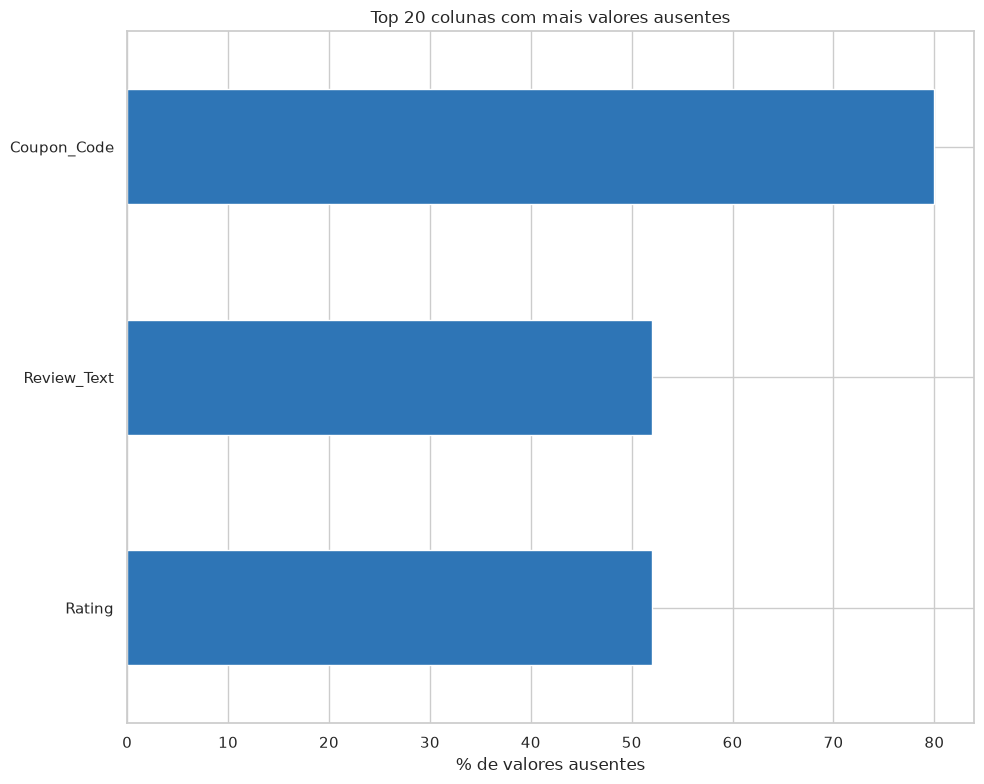

In [32]:
# Visualizando as colunas com mais valores ausentes
plt.figure(figsize=(10, 8))
tabela_ausentes["pct_ausentes"].head(20).sort_values().plot(kind="barh", color="#2E75B6")
plt.xlabel("% de valores ausentes")
plt.title("Top 20 colunas com mais valores ausentes")
plt.tight_layout()
plt.show()

# 4. Detecção de Outliers:

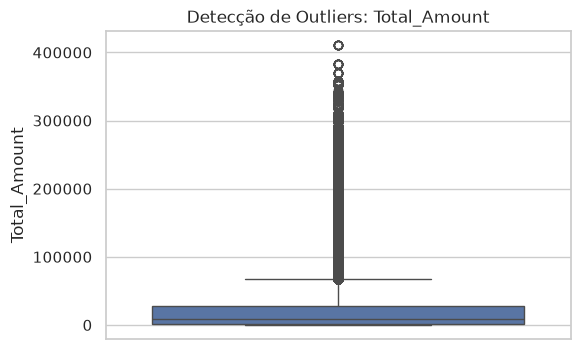

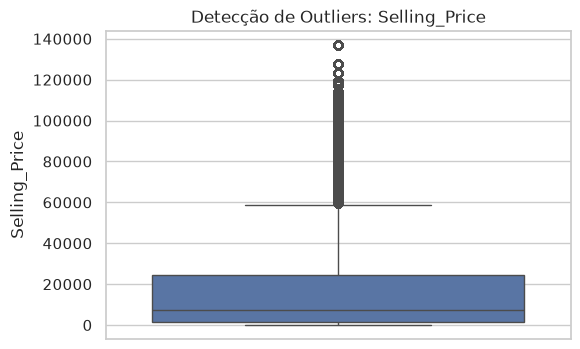

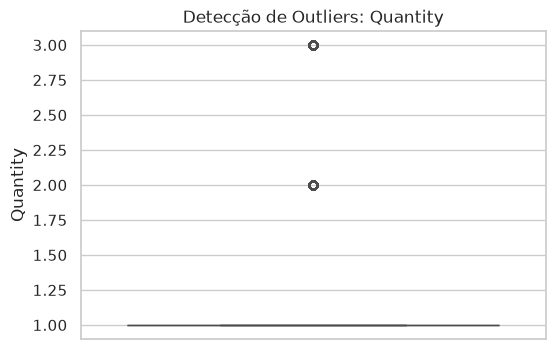

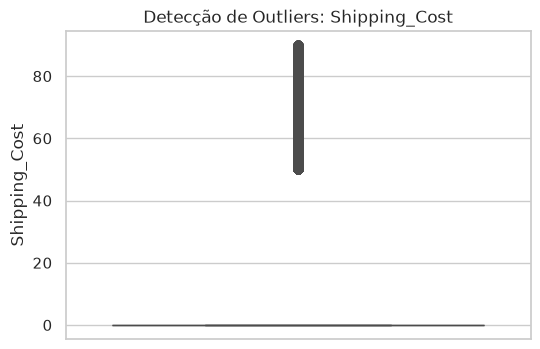

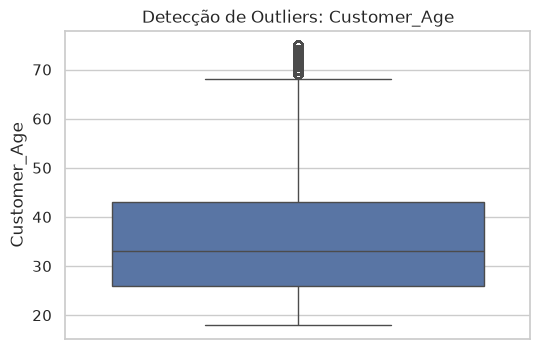

In [46]:
# Seleção manual das colunas que realmente importam para o negócio
colunas_selecionadas = [
    'Total_Amount',   # Valor final total da compra
    'Selling_Price',  # Preço de venda do produto
    'Quantity',       # Volume de itens comprados
    'Shipping_Cost',  # Custo de frete
    'Customer_Age'    # Idade (para checar possíveis erros de digitação)
]

# Gera 5 gráficos precisos
for coluna in colunas_selecionadas:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df_dataset[coluna])
    plt.title(f'Detecção de Outliers: {coluna}')
    
    # Salva cada gráfico limpo na pasta exigida pelo professor
    plt.savefig(f'../reports/figures/outliers_{coluna.lower()}.png')
    
    plt.show()